In [1]:
import cv2
from PIL import Image
import os
import numpy as np
import pyheif
import matplotlib.pyplot as plt

In [2]:
def check_edge(gray):
    """
    그레이 스케일 이미지가 들어오면
    사각형을 찾은 후
    4개의 꼭지점 반환
    """
    ret, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

    contours, hierarchy = cv2.findContours(
        thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    areas = []
    perimeters = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        perimeter = cv2.arcLength(cnt, True)
        areas.append(area)
        perimeters.append(perimeter)
    
    cnt = contours[np.argmax(areas).item()]
    approx = cv2.approxPolyDP(cnt, 0.02 * cv2.arcLength(cnt, True), True)
    if len(approx)!=4:
        print('사각형을 찾지 못했습니다.')
        print(f'{len(approx)}각형을 찾았습니다.')
        raise Exception('사각형이 아닙니다. 계산 할 수 없습니다.')
    approx = approx.reshape(len(approx),2)
    x_bar = np.mean(approx[:,0])
    y_bar = np.mean(approx[:,1])
    x_down = approx[approx[:,0] < x_bar]
    x_up = approx[approx[:,0] >= x_bar]
    points = np.array([x_down[x_down[:,1] < y_bar][0],x_up[x_up[:,1] < y_bar][0],x_up[x_up[:,1] >= y_bar][0],x_down[x_down[:,1] >= y_bar][0]])
    return points

In [3]:
approx = np.array([[1,2],[1,9],[8,8],[7,3]])
x_bar = np.mean(approx[:,0])
y_bar = np.mean(approx[:,1])
x_down = approx[approx[:,0] < x_bar]
x_up = approx[approx[:,0] >= x_bar]
x_down[x_down[:,1] < y_bar]

array([[1, 2]])

In [4]:
# 이미지 사이즈 처리 및 그레이 스케일 변환
def read_img(path, img_type=None):
    """
    이미지 사이즈 --> 2000x1500
    그레이 스케일 변환
    """
    if img_type is None:
        img_type = os.path.splitext(path)[-1]
    if img_type=='.HEIC':
        print('this image is HEIC!')
        heif_file = pyheif.read(path)
        img = Image.frombytes(
        heif_file.mode,
        heif_file.size,
        heif_file.data,
        "raw",
        heif_file.mode,
        heif_file.stride,
        )
        img = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
    elif img_type=='.jpg' or '.png':
        img = cv2.imread(path)
    else:
        raise Exception('처리할 수 없는 확장자 입니다.')
    return img

In [5]:
def cv_imshow(img,cn=None):
    if cn is None:
        if len(np.array(img).shape) == 3:
            cn = np.array(img).shape[-1]
            print(f'this channel is {cn}')
        elif len(np.array(img).shape) == 2:
            cn = 1
            print(f'this is gray scale')
        else:
            raise Exception('이미지를 처리할 수 없습니다.')
    if cn==3:
        rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
        plt.imshow(rgb)
    elif cn==1:
        plt.imshow(img,cmap='gray')
    plt.show()

In [6]:
def target_points(ra=(1.414,1),target=1732): ############ 만약에 이미지가 회전되면 위치 포인트 순서 맞추는 작업을 추가해야함 ######################
    """
    ra는 (h,w) 비율
    대각선 길이가 1732를 목표로 함
    """
    b = target / (ra[0]**2+ra[1]**2)**0.5
    ra = np.array(ra)
    hw = ra*b
    return np.array([[0,0],[hw[1],0],[hw[1],hw[0]],[0,hw[0]]], dtype=np.int32)

In [7]:
img_path = '/home/kim/google_drive/OTHERS/IMG_4129.HEIC'

this image is HEIC!
this channel is 3


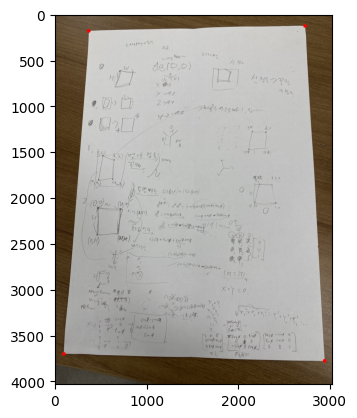

In [8]:
img = read_img(img_path)
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
points = check_edge(gray)
for pnt in points:
    cv2.circle(img,pnt,20,(0,0,255),-1)
cv_imshow(img)

In [9]:
t_pnts = target_points()
t_pnts

array([[   0,    0],
       [1000,    0],
       [1000, 1414],
       [   0, 1414]], dtype=int32)

In [10]:
points = points.astype(np.float32)
t_pnts = t_pnts.astype(np.float32)

In [11]:
points

array([[ 367.,  184.],
       [2720.,  129.],
       [2933., 3779.],
       [  96., 3703.]], dtype=float32)

In [12]:
mat = cv2.getPerspectiveTransform(points,t_pnts)

In [13]:
w = 1000
h = 1414

this channel is 3


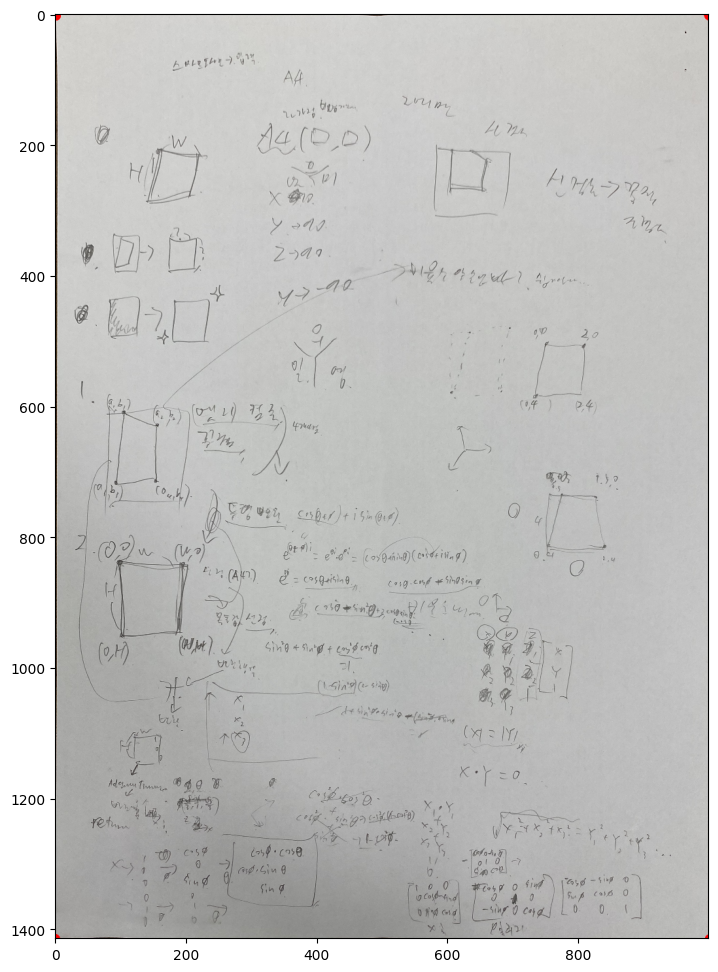

In [14]:
result = cv2.warpPerspective(img,mat,(w,h))
plt.figure(figsize=(12,12))
cv_imshow(result)